Dataset Upload

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Dataset .csv to Dataset .csv


Import Libraries

In [2]:
# Restaurant Data Analysis

## Section 1: Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [4]:
## Section 2: Load Dataset

In [11]:
import os

os.listdir()

['.config', 'Dataset .csv', 'sample_data']

In [12]:
df = pd.read_csv("Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


Data Understanding

In [13]:
df.shape

(9551, 21)

In [14]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [16]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


Data Cleaning

In [17]:
df = df.drop_duplicates()

df['Cuisines'] = df['Cuisines'].fillna('Unknown')

df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


# Level 2 - Task 1: Restaurant Ratings Analysis

## Objective

Analyze the distribution of aggregate ratings and calculate the average number of votes received by restaurants.

In [18]:
rating_counts = df['Aggregate rating'].value_counts().sort_index()

rating_counts

,count
Aggregate rating,
0.0,2148
1.8,1
1.9,2
2.0,7
2.1,15
2.2,27
2.3,47
2.4,87
2.5,110


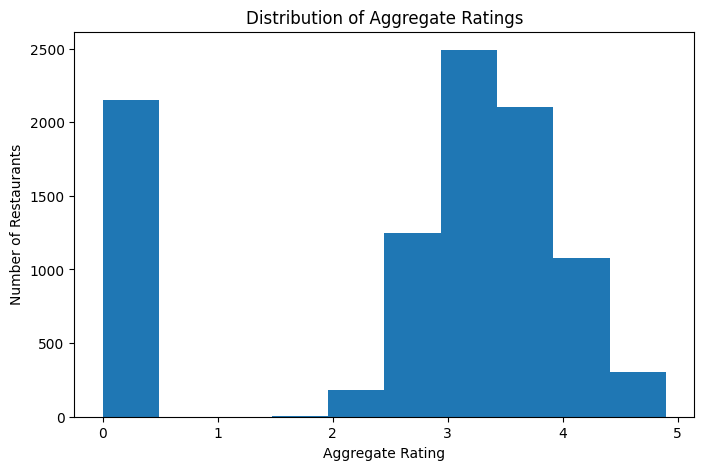

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df['Aggregate rating'], bins=10)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.show()

In [20]:
average_votes = df['Votes'].mean()

average_votes

np.float64(156.909747670401)

## Observation

- The distribution of aggregate ratings shows that most restaurants have ratings between 3.0 and 4.0.
- A large number of restaurants have a rating of 0.0, indicating that they are either not rated or have not received customer ratings.
- Very few restaurants have ratings below 2.0 or above 4.5.
- The average number of votes received by restaurants is approximately 156.91.

## Conclusion

The analysis indicates that most restaurants have good customer ratings, generally between 3.0 and 4.0. Although many restaurants have not received ratings (0.0), the average number of votes (156.91) suggests that customers actively rate and review restaurants in the dataset.

# Level 2 - Task 2: Cuisine Combination Analysis

## Objective

Identify the most common cuisine combinations and analyze whether certain cuisine combinations have higher average ratings.

In [21]:
cuisine_combination = df['Cuisines'].value_counts()

cuisine_combination.head(10)

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Fast Food,354
Chinese,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


In [22]:
cuisine_rating = df.groupby('Cuisines')['Aggregate rating'].mean()

cuisine_rating.sort_values(ascending=False).head(10)

,Aggregate rating
Cuisines,
"Italian, Deli",4.9
"American, Coffee and Tea",4.9
"American, BBQ, Sandwich",4.9
"BBQ, Breakfast, Southern",4.9
"Italian, Bakery, Continental",4.9
"American, Burger, Grill",4.9
"Hawaiian, Seafood",4.9
"Mexican, American, Healthy Food",4.9
"American, Caribbean, Seafood",4.9


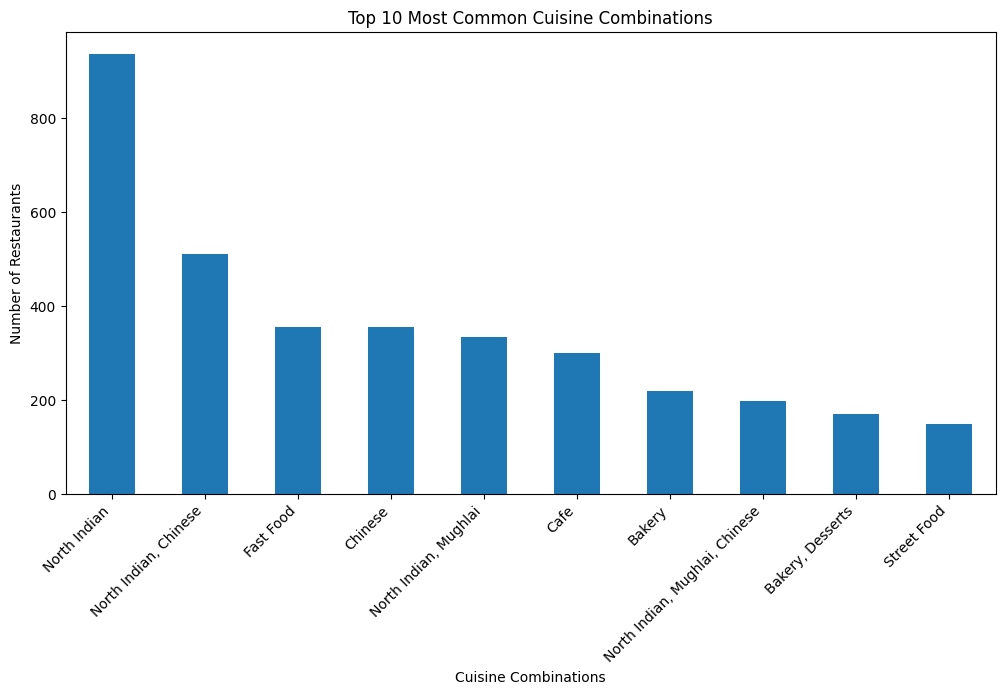

In [23]:
plt.figure(figsize=(12,6))

cuisine_combination.head(10).plot(kind='bar')

plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Cuisine Combinations")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45, ha='right')

plt.show()

## Observation

- North Indian is the most common cuisine combination with 936 restaurants.
- North Indian, Chinese is the second most common cuisine combination with 511 restaurants.
- Fast Food and Chinese cuisines are also popular among restaurants.
- Some cuisine combinations such as Italian, Deli and American, Coffee and Tea have the highest average rating of 4.9.
- Popular cuisine combinations do not always have the highest ratings.

## Conclusion

The analysis shows that North Indian and North Indian, Chinese are the most common cuisine combinations in the dataset. However, the highest-rated cuisine combinations are different, with several combinations achieving an average rating of 4.9. This indicates that popularity and customer ratings are not always directly related.

# Level 2 - Task 3: Geographic Analysis

## Objective

Analyze the geographical distribution of restaurants using latitude and longitude coordinates and identify clusters of restaurants.

In [24]:
!pip install folium

In [25]:
import folium

In [26]:
restaurant_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=2
)

restaurant_map

In [27]:
restaurant_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=2
)

for i in range(100):
    folium.Marker(
        location=[df.iloc[i]['Latitude'], df.iloc[i]['Longitude']],
        popup=df.iloc[i]['Restaurant Name']
    ).add_to(restaurant_map)

restaurant_map

## Observation

- The map displays restaurant locations using latitude and longitude coordinates.
- Restaurants are spread across different countries and cities.
- Multiple restaurant locations are concentrated in specific regions, forming visible clusters.
- The visualization indicates that restaurants are more densely located in urban areas.

## Conclusion

The geographic analysis shows that restaurants are not evenly distributed. Most restaurants are concentrated in major cities and urban regions, creating clusters. Mapping restaurant locations helps identify areas with high restaurant density.

# Level 2 - Task 4: Restaurant Chains Analysis

## Objective

Identify restaurant chains in the dataset and analyze their ratings and popularity.

In [28]:
restaurant_chains = df['Restaurant Name'].value_counts()

restaurant_chains.head(10)

,count
Restaurant Name,
Cafe Coffee Day,83
Domino's Pizza,79
Subway,63
Green Chick Chop,51
McDonald's,48
Keventers,34
Pizza Hut,30
Giani,29
Baskin Robbins,28


In [29]:
chain_analysis = df.groupby('Restaurant Name').agg({
    'Aggregate rating': 'mean',
    'Votes': 'mean'
})

chain_analysis.sort_values(by='Votes', ascending=False).head(10)

,Aggregate rating,Votes
Restaurant Name,,
Toit,4.80,10934.0
Hauz Khas Social,4.30,7931.0
Peter Cat,4.30,7574.0
Big Brewsky,4.50,5705.0
The Black Pearl,4.10,5385.0
BarBQ,4.20,5288.0
Warehouse Cafe,3.70,4914.0
Truffles,3.95,4841.0
Mocambo,3.50,4464.0


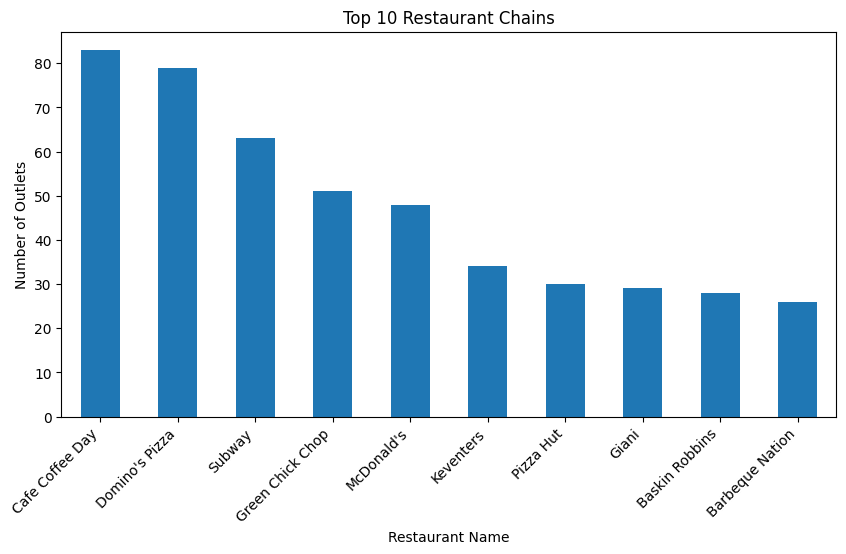

In [30]:
top_chains = df['Restaurant Name'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_chains.plot(kind='bar')

plt.title("Top 10 Restaurant Chains")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Outlets")

plt.xticks(rotation=45, ha='right')

plt.show()

## Observation

- Cafe Coffee Day is the largest restaurant chain in the dataset with 83 outlets.
- Domino's Pizza is the second largest chain with 79 outlets.
- Subway, Green Chick Chop, and McDonald's are also among the most common restaurant chains.
- Restaurants such as Toit, Hauz Khas Social, and Peter Cat have the highest average customer votes, indicating high popularity.
- Well-known restaurant chains generally have good customer engagement and ratings.

## Conclusion

The analysis shows that several restaurant chains operate across multiple locations. Cafe Coffee Day, Domino's Pizza, and Subway have the highest number of outlets, while restaurants like Toit and Hauz Khas Social receive the highest customer engagement through votes. This suggests that strong brand presence and good customer experience contribute to restaurant popularity.